In [1]:
import os
import sys
from itertools import product

sys.path.append("../")

envkey = "OMP_NUM_THREADS"
# Set this environment variable to the number of available cores in your machine,
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(12)
os.environ[envkey] = str(12)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  12


In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import seaborn
import pandas as pd

try:
    import niceplots.utils as nicepl
    nicepl.initPlot()
except:
    pass

Cs = seaborn.color_palette("colorblind")
Cp = seaborn.color_palette("Paired")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
from SSLimPy.interface import sslimpy
from SSLimPy.interface import updater

In [4]:
# For a full list of options look at the config module

settings = {
    "code":"class", # The Einstein--Boltzman solver that should be used
    "do_RSD" : True, # If RSD should be considerd
    "nonlinearRSD" : True, # If you want to add FOG to the RSD
    "QNLpowerspectrum": True, # Use dewiggled power spectrum (vlasov approximation of nonlinear structure formation)
    "FoG_damp" : "ISTF_like", # The particular parametrization for the FOG. Check PowerSpectrum for the full list
    "halo_model_PS" : True, # If the cosmological shotnoise should be computed from the halo model 
    "output" : ["Power spectrum", "Covariance"], # What output one wants (here power spectrum and Gaussian covariance only)
    "nonlinearMatpow": False, #If the EBS should compute the nonlinear power spectrum
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 10 * u.Mpc**-1,
    "nk": 50,
}

In [5]:
# Has a unified way to pass comsological input parameters
cosmodict = {
    "h":0.70,
    "Omegam":0.3,
    "As":2.1e-9,
    "Omegab":0.05,
}

In [6]:
myssl = sslimpy.SSLimPy(settings_dict=settings, cosmopars=cosmodict)

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


# The cosmology calculatior

In [7]:
mycosmo = myssl.current_cosmology # fiducial cosmology model

# Different parameters were set to deffault values
cosmodict_fid = mycosmo.cosmopars
cosmodict_fid

{'h': 0.7,
 'Omegam': 0.3,
 'As': 2.1e-09,
 'Omegab': 0.05,
 'ns': 0.96,
 'alpha_s': 0.0,
 'mnu': 0.06,
 'Neff': 3.044}

In [8]:
# update cosmogy
cosmodict_2 = cosmodict_fid.copy()
cosmodict_2["Omegam"] = 0.34

mycosmo_highm = updater.update_cosmo(mycosmo, cosmodict_2, myssl.cfg)

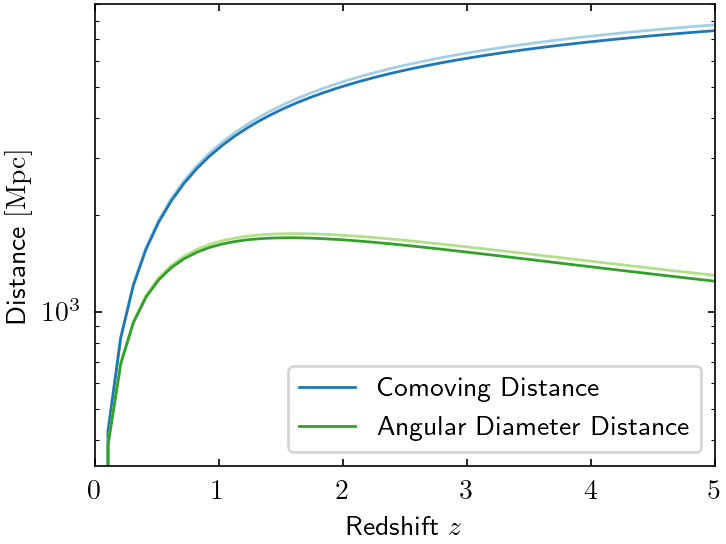

In [9]:
# Plot some distances
z = np.linspace(0, 5)
D_M = mycosmo.comoving(z)
D_M_2 = mycosmo_highm.comoving(z)
D_A = mycosmo.angdist(z)
D_A_2 = mycosmo_highm.angdist(z)

color = iter(Cp)

plt.semilogy(z, D_M, c=next(color))
plt.semilogy(z, D_M_2, c=next(color), label="Comoving Distance")
plt.semilogy(z, D_A, c=next(color))
plt.semilogy(z, D_A_2, c=next(color), label="Angular Diameter Distance ")
plt.xlabel("Redshift $z$")
plt.ylabel(r"Distance $[\mathrm{Mpc}]$")
plt.legend()


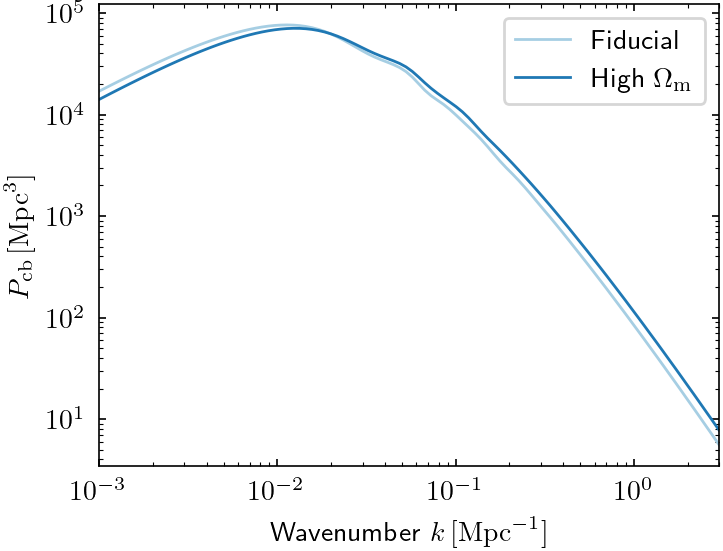

In [18]:
k = np.geomspace(1e-3, 3, 100) * u.Mpc**-1
Pk_cb = mycosmo.matpow(k, 0, nonlinear=False, tracer="clustering")
Pk_cb_2 = mycosmo_highm.matpow(k, 0, nonlinear=False, tracer="clustering")

color = iter(Cp)
plt.loglog(k, Pk_cb, c=next(color), label="Fiducial")
plt.loglog(k, Pk_cb_2, c=next(color), label=r"High $\Omega_\mathrm{m}$")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{\rm cb}\,[\mathrm{Mpc}^3]$")
plt.legend()

# Testing the Halo and Astro Module

In [19]:
halo_dict = {
    # Choose Halo mass functions and bias 
    "hmf_model": "Tinker",
    "bias_model":"Tinker05",
    "bias_pars": {
        "a":0.707,
        "b":0.35,
        "c":0.8,
    },
    # Choices for HM power spectrum parameterisation
    "transition_smoothing":True,
    "halo_tracer":"clustering"
}

myhalo = updater.update_halomodel(
    myssl.current_halomodel, cosmodict_fid, halo_dict, myssl.cfg
)

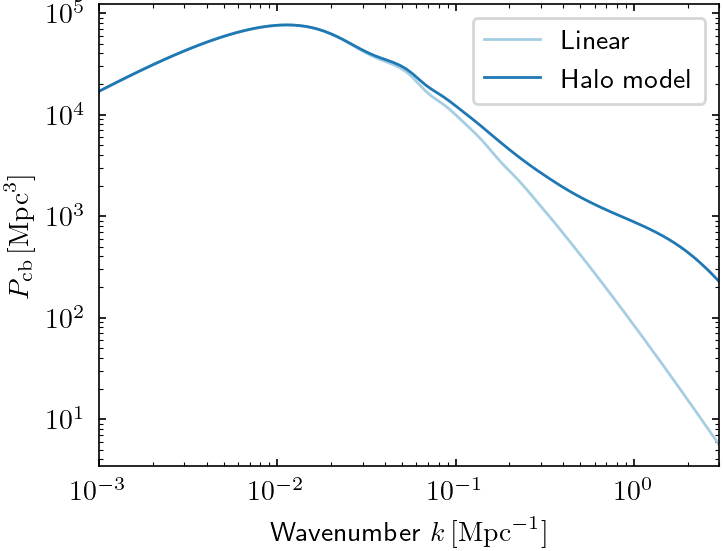

In [20]:
Pk_nl_cb = myhalo.P_halo(k, 0)

color = iter(Cp)
plt.loglog(k, Pk_cb, c=next(color), label="Linear")
plt.loglog(k, Pk_nl_cb, c=next(color), label=r"Halo model")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{\rm cb}\,[\mathrm{Mpc}^3]$")
plt.legend()

# Specify Line and Expermiment

In [21]:
survey_dict = {
        "Tsys_NEFD": 40 * u.uK, #System temperature for instrumental shotnoise
        "Nfeeds": 19,
        "tobs": 1300 * u.h,
        "nD": 1, # Observational parameters
        "beam_FWHM": 0.5 * u.arcmin,
        "nu":  1.897 * u.THz, # CII
        "dnu": 900 * u.MHz, # Spectrograph resolution
        "nuObs": 250 * u.GHz, # Observed Frequency
        "Delta_nu": 50 * u.GHz, # Frequency Bin
        "Omega_field": 140 * u.deg**2, # Angular size of survey
}

astrodict_CII={
    # Mass--Luminosity Relation
    "model_type": "ML",
    "model_name": "SilvaCII", # Parametrise CII as power law in SFR
    "model_par": {
        "a": 0.8475,
        "b": 7.2203,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37, # Add meanperserving log normal scatter to the Luminosity
    "meanperserve_scatter": True,
}

myastro = updater.update_astro(
    myssl.current_astro, cosmodict_fid, halo_dict, astrodict_CII, survey_dict, myssl.cfg
)

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0, 0.5, 'Line Temperature $T_{\\rm [CII]}\\,[\\mu \\mathrm{K}]$')

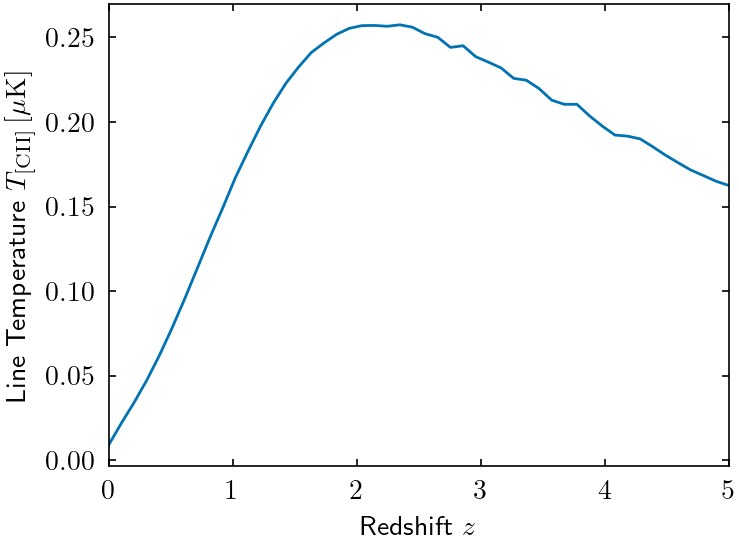

In [22]:
T = myastro.Tavg(z)
plt.plot(z, T, c=Cs[0])
plt.xlabel("Redshift $z$")
plt.ylabel(r"Line Temperature $T_{\rm [CII]}\,[\mu \mathrm{K}]$")


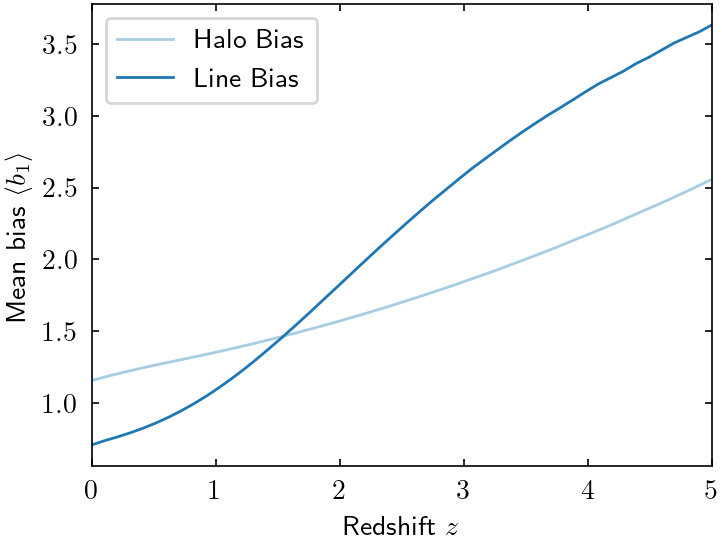

In [23]:
b_h = myhalo.bavg(1, z, 1)
b_L = myastro.bavg(1, z, 1)

color = iter(Cp)
plt.plot(z, b_h, c=next(color), label="Halo Bias")
plt.plot(z, b_L, c=next(color), label="Line Bias")
plt.xlabel("Redshift $z$")
plt.ylabel(r"Mean bias $\langle b_1 \rangle$")
plt.legend()

# Obtain Power Spectra and Covariances

In [24]:
# power spectrum quantities can be passed in parametric form
bao_dict = {
    "sigmap" : 1.8 * u.Mpc, # FOG amplitude
    "Tmean" : 0.1 * u.uK, # Line temperature
    "bmean" : 4.4, # linear bias
}

# tweak k range on the fly
pobs_settings = {
    "kmin" : 1e-3 * u.Mpc**-1,
    "kmax" : 1 * u.Mpc**-1,
    "nk" : 40,
}

In [25]:
output = myssl.compute(
    cosmodict_fid, halo_dict, astrodict_CII, survey_dict,
    pobs_settings=pobs_settings, BAOpars=bao_dict,
    output=["Power spectrum", "Covariance"],
)
pobs_CII, cov_CII = output["Power spectrum"], output["Covariance"]

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


(np.float64(0.0011517327369000795), np.float64(0.9188388200341462))

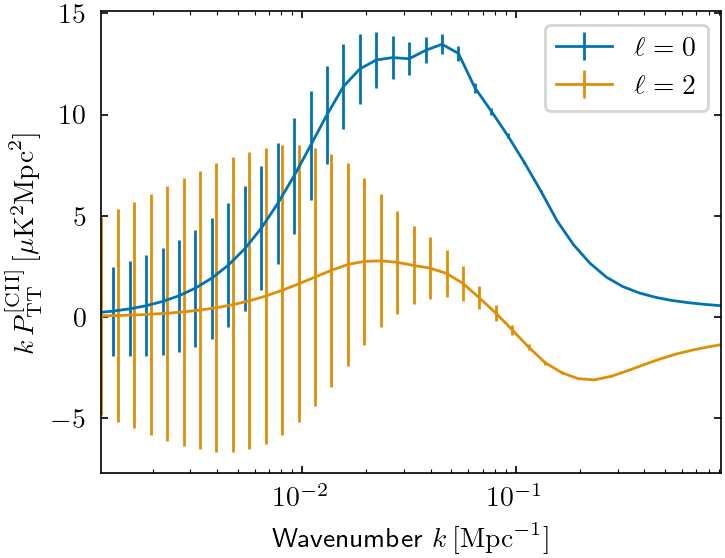

In [26]:
k = pobs_CII.k
Pk_0 = pobs_CII.Pk_0bs.squeeze()
Pk_2 = pobs_CII.Pk_2bs.squeeze()

cov = cov_CII.gaussian_cov().squeeze()
ePk_0 = cov[:, 0, 0]
ePk_2 = cov[:, 1, 1]

plt.errorbar(k, k * Pk_0, k * np.sqrt(ePk_0), c=Cs[0], label=r"$\ell=0$")
plt.errorbar(k * (1 + 0.05), k * Pk_2, k * np.sqrt(ePk_2), c=Cs[1], label=r"$\ell=2$")
plt.semilogx()
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P_{\rm TT}^{\rm [CII]}\,[\mu \mathrm{K}^2\mathrm{Mpc}^2]$")
plt.legend()
plt.xlim(k.min().value * (1 + 0.05), k.max().value)

# Do a Quick Fisher Forecast

In [27]:
Cov = np.block([
    [np.diag(cov[:, 0, 0]), np.diag(cov[:, 1, 0])],
    [np.diag(cov[:, 0, 1]), np.diag(cov[:, 1, 1])]
])
invCov = np.linalg.inv(Cov)

In [28]:
deriv_dict = {}

eps = 1e-2
cosmopars = ["h", "Omegam", "As", "ns"]
for param in cosmopars:
    cosmodict = cosmodict_fid.copy()
    cosmodict[param] = cosmodict_fid[param] * (1 + eps)
    pobs = myssl.compute(
        cosmodict, halo_dict, astrodict_CII, survey_dict, bao_dict, pobs_settings, ["Power spectrum"]
    )["Power spectrum"]
    pp = np.concatenate((pobs.Pk_0bs.squeeze(), pobs.Pk_2bs.squeeze()), axis=0)

    cosmodict[param] = cosmodict_fid[param] * (1 - eps)
    pobs = myssl.compute(
        cosmodict, halo_dict, astrodict_CII, survey_dict, bao_dict, pobs_settings, ["Power spectrum"]
    )["Power spectrum"]
    mp = np.concatenate((pobs.Pk_0bs.squeeze(), pobs.Pk_2bs.squeeze()), axis=0)
    deriv_dict[param] = (pp - mp) / (2 * eps * cosmodict_fid[param])

baopars = ["sigmap", "Tmean", "bmean"]
for param in baopars:
    bao_dict_2 = bao_dict.copy()
    bao_dict_2[param] = bao_dict[param] * (1 + eps)
    pobs = myssl.compute(
        cosmodict_fid, halo_dict, astrodict_CII, survey_dict, bao_dict_2, pobs_settings, ["Power spectrum"]
    )["Power spectrum"]
    pp = np.concatenate((pobs.Pk_0bs.squeeze(), pobs.Pk_2bs.squeeze()), axis=0)

    bao_dict_2[param] = bao_dict[param] * (1 - eps)
    pobs = myssl.compute(
        cosmodict_fid, halo_dict, astrodict_CII, survey_dict, bao_dict_2, pobs_settings, ["Power spectrum"]
    )["Power spectrum"]
    mp = np.concatenate((pobs.Pk_0bs.squeeze(), pobs.Pk_2bs.squeeze()), axis=0)
    deriv_dict[param] = (pp - mp) / (2 * eps * bao_dict[param])

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


In [29]:
params = cosmopars + baopars
npar = len(params)
Fisher = np.zeros((npar, npar))

In [30]:
params = cosmopars + baopars
npar = len(params)
Fisher = np.zeros((npar, npar))

for i, pi in enumerate(params):
    dmu_i = deriv_dict[pi]

    for j, pj in enumerate(params):
        dmu_j = deriv_dict[pj]

        Fisher[i, j] = (dmu_i @ invCov @ dmu_j).value

print(Fisher)

pCov = np.linalg.inv(Fisher)
sigma = np.sqrt(np.diag(pCov))

pCorr = pCov / np.outer(sigma, sigma)

[[ 9.16875471e+08  1.77148229e+09  1.24108666e+17  7.35406550e+08
  -1.39438621e+06  4.13750578e+08  9.25194984e+06]
 [ 1.77148229e+09  3.42391911e+09  2.40042722e+17  1.42106939e+09
  -2.74494603e+06  8.16007376e+08  1.82323268e+07]
 [ 1.24108666e+17  2.40042722e+17  1.68525061e+25  9.95845842e+16
  -1.98155554e+14  5.94848914e+16  1.32755235e+15]
 [ 7.35406550e+08  1.42106939e+09  9.95845842e+16  5.89896390e+08
  -1.12378893e+06  3.34344034e+08  7.47489570e+06]
 [-1.39438621e+06 -2.74494603e+06 -1.98155554e+14 -1.12378893e+06
   6.76530098e+03 -1.29012862e+06 -2.78204707e+04]
 [ 4.13750578e+08  8.16007376e+08  5.94848914e+16  3.34344034e+08
  -1.29012862e+06  4.20031935e+08  9.21970160e+06]
 [ 9.25194984e+06  1.82323268e+07  1.32755235e+15  7.47489570e+06
  -2.78204707e+04  9.21970160e+06  2.02683029e+05]]


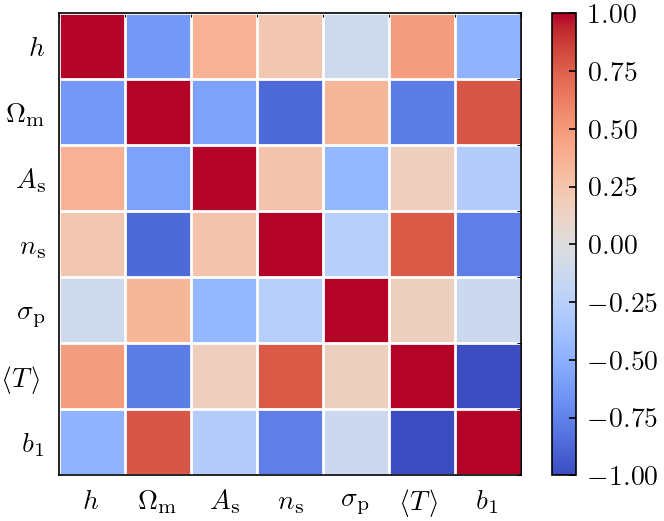

In [ ]:
latexnames = {
    "h" : "$h$",
    "Omegam": r"$\Omega_\mathrm{m}$",
    "As": r"$A_\mathrm{s}$",
    "ns": r"$n_\mathrm{s}$",
    "sigmap": r"$\sigma_\mathrm{p}$",
    "Tmean":r"$\langle T \rangle$",
    "bmean": "$b_1$",
}
labels = [latexnames[p] for p in params]

fig, ax = plt.subplots()
im = ax.imshow(pCorr, vmin=-1, vmax=1, cmap="coolwarm")


ax.set_xticks(np.arange(npar))
ax.set_xticklabels(labels)
ax.set_yticks(np.arange(npar))
ax.set_yticklabels(labels)
ax.tick_params(axis='both', which='major', length=0)

ax.set_xticks(np.arange(-0.5, npar, 1), minor=True)
ax.set_yticks(np.arange(-0.5, npar, 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params()

In [32]:
latexnames = {
    "h" : "$h$",
    "Omegam": r"$\Omega_\mathrm{m}$",
    "As": r"$A_\mathrm{s}$",
    "ns": r"$n_\mathrm{s}$",
    "sigmap": r"$\sigma_\mathrm{p}\,[\mathrm{Mpc}]$",
    "Tmean":r"$\langle T \rangle\,[\mu \mathrm{K}]$",
    "bmean": "$b_1$",
}

fid = [
    cosmodict_fid["h"],
    cosmodict_fid["Omegam"],
    cosmodict_fid["As"],
    cosmodict_fid["ns"],
    bao_dict["sigmap"].value,
    bao_dict["Tmean"].value,
    bao_dict["bmean"],
]

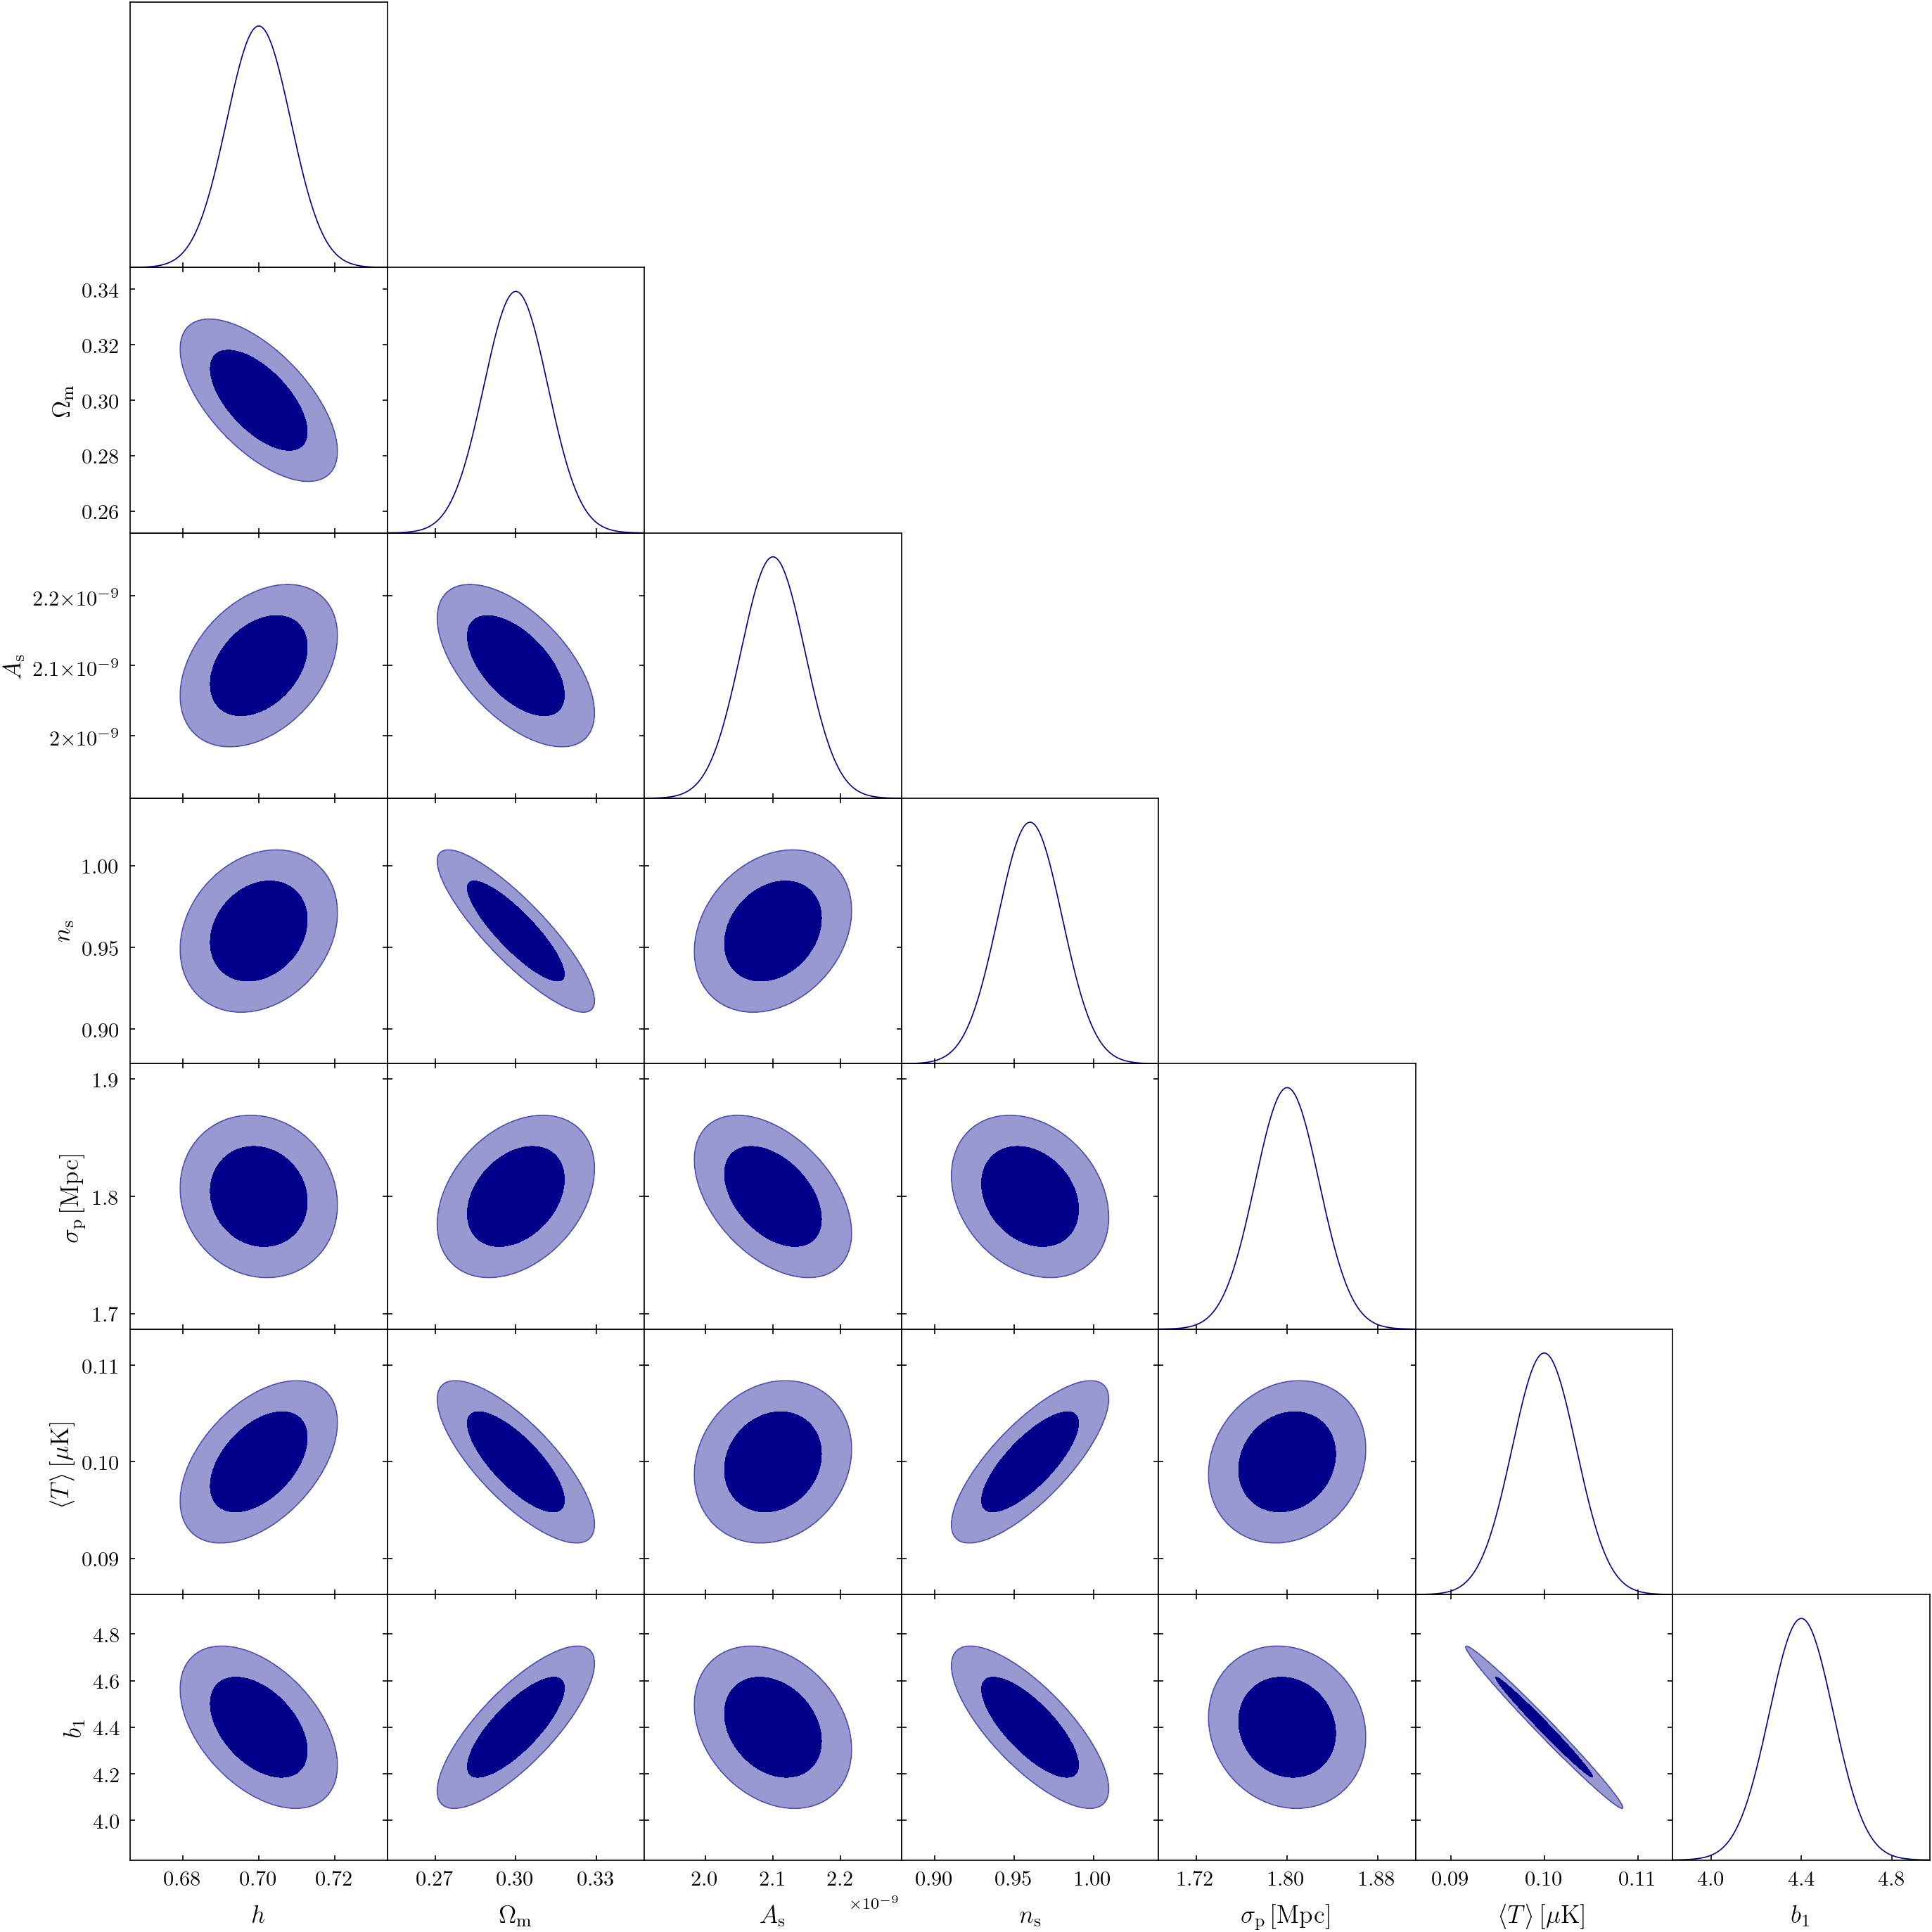

In [33]:
from getdist.gaussian_mixtures import GaussianND
from getdist import plots

# covariance from Fisher
pCov = np.linalg.inv(Fisher)

# parameter names
names = params

# GetDist labels (WITHOUT outer $)
labels = [latexnames[p].replace("$", "") for p in params]

# Gaussian posterior directly from mean + covariance
gauss = GaussianND(
    mean=fid,
    cov=pCov,
    names=names,
    labels=labels
)

# plot
g = plots.get_subplot_plotter()

g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14

g.triangle_plot(
    gauss,
    filled=True,
    contour_colors=["darkblue"]
)

plt.show()